In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [22]:
import kagglehub

path = kagglehub.dataset_download(
    "faysalmiah1721758/potato-dataset",
    output_dir="./data"
)

print("Dataset downloaded to:", path)

Dataset downloaded to: ./data


In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

I0000 00:00:1790408717.704293   10872 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790408719.062554   10872 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790408749.409678   10872 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [82]:
IMAGESIZE=256
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/d/Projects/Potato_Desiese/data",
    image_size=(256,256),
    shuffle=True,
    batch_size=16
)

Found 2152 files belonging to 3 classes.


In [83]:
class_names=dataset.class_names


In [85]:
class_name_index = {0:'Potato___Early_blight', 1:'Potato___Late_blight',2:'Potato___healthy'}

In [4]:
dataset.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [5]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy)

(16, 256, 256, 3)
<bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(16,), dtype=int32, numpy=array([0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1], dtype=int32)>>


In [6]:

import matplotlib.pyplot as plt

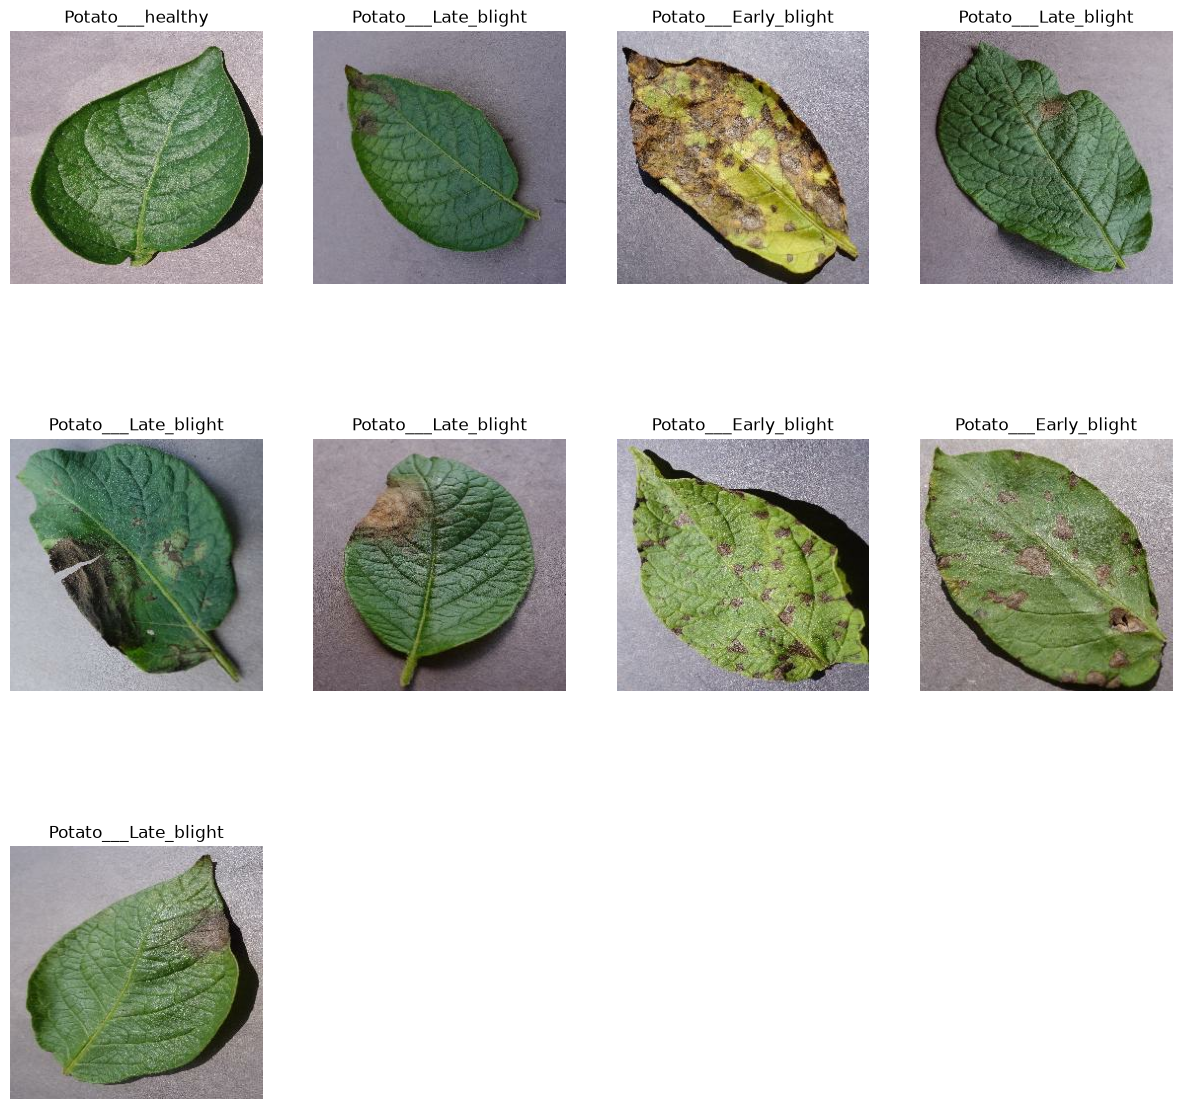

In [7]:
plt.figure(figsize=(15,15))
for image_batch,label_batch in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [8]:
len(dataset)

135

In [9]:
train_size=0.8
len(dataset)*train_size

108.0

In [10]:
train_ds=dataset.take(54)

In [11]:
test_ds = dataset.skip(54)

In [12]:
val_size=0.1
len(dataset)*val_size

13.5

In [13]:
test_ds=test_ds.skip(6)

In [14]:
def get_train_test_split(ds,train_split=0.8,test_split=0.1,val_split=0.1):
    ds_size=len(ds)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    train_ds = ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).take(val_size)
    return train_ds,val_ds,test_ds

In [15]:
train_ds,val_ds,test_ds=get_train_test_split(dataset)

In [16]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [17]:
import tensorflow as tf

In [18]:
model = tf.keras.Sequential()


In [19]:
model = tf.keras.Sequential()

In [20]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(None, None, 3)))

model.add(tf.keras.layers.Resizing(256, 256))
model.add(tf.keras.layers.Rescaling(1./255))

model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(3,activation='softmax'))




In [21]:
model.compile()

In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,419 (1.68 MB)

 Trainable params: 440,419 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='adam',loss=['sparse_categorical_crossentropy'],metrics=['accuracy'])

In [29]:
history=model.fit(train_ds,epochs=50)

Epoch 1/50
  5/108 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 9.4525e-05

/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 4.5897e-05
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 3.8926e-05
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 3.4238e-05
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 3.1594e-05
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 2.9402e-05
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 2.6452e-05
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 2.4461e-05
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 2.1824e-05
Epoch 9/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 2.0161e-05
Epoch 10/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 1.8472e-05
Epoch 11/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 1.6834e-05
Epoch 12

In [32]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

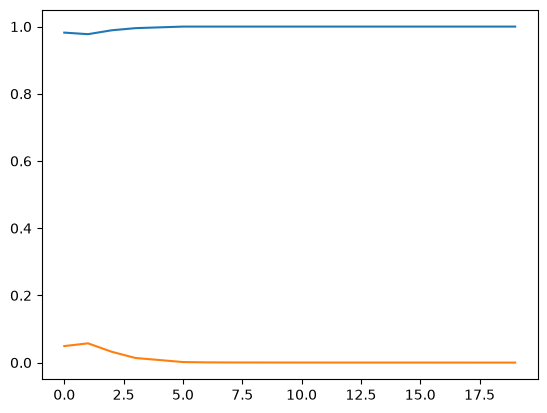

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_a'])
plt.plot(history.history['loss'])

In [28]:
scores = model.evaluate(test_ds)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9567 - loss: 0.2511


In [ ]:
model.predict()

In [34]:
image_batch = dataset.take(1)

In [42]:
batch =[]
for image in dataset:
    batch+=image

In [54]:
batch[0][0].shape

TensorShape([256, 256, 3])

In [78]:
import numpy as np
response = model.predict(batch[0])
print(type(response))
result  = response[0]
print(np.argmax(result))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
<class 'numpy.ndarray'>
0


Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted Potato___Early_blight


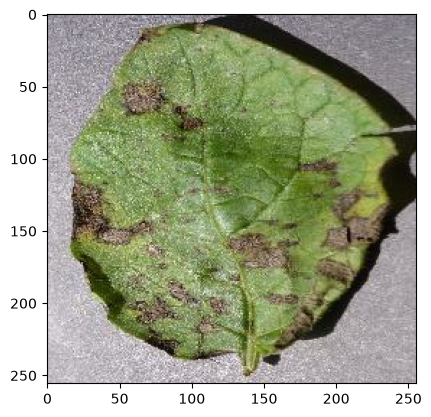

In [93]:
plt.imshow(batch[0][0].numpy().astype('uint8'))
first_label = batch[0][0].numpy()
print(class_names[0])
print("Predicted",class_name_index[np.argmax(model.predict(batch[0])[0])])

In [92]:
class_name_index[0]

'Potato___Early_blight'

In [127]:
import numpy as np
import tensorflow as tf

def predict(model, img):
    img = tf.expand_dims(img,axis=0)
    prediction = model.predict(img, verbose=0)

    # Get index of highest probability
    predicted_class = np.argmax(prediction[0])

    # Get confidence
    confidence = round(float(np.max(prediction[0])) * 100, 2)

    return class_names[predicted_class], confidence

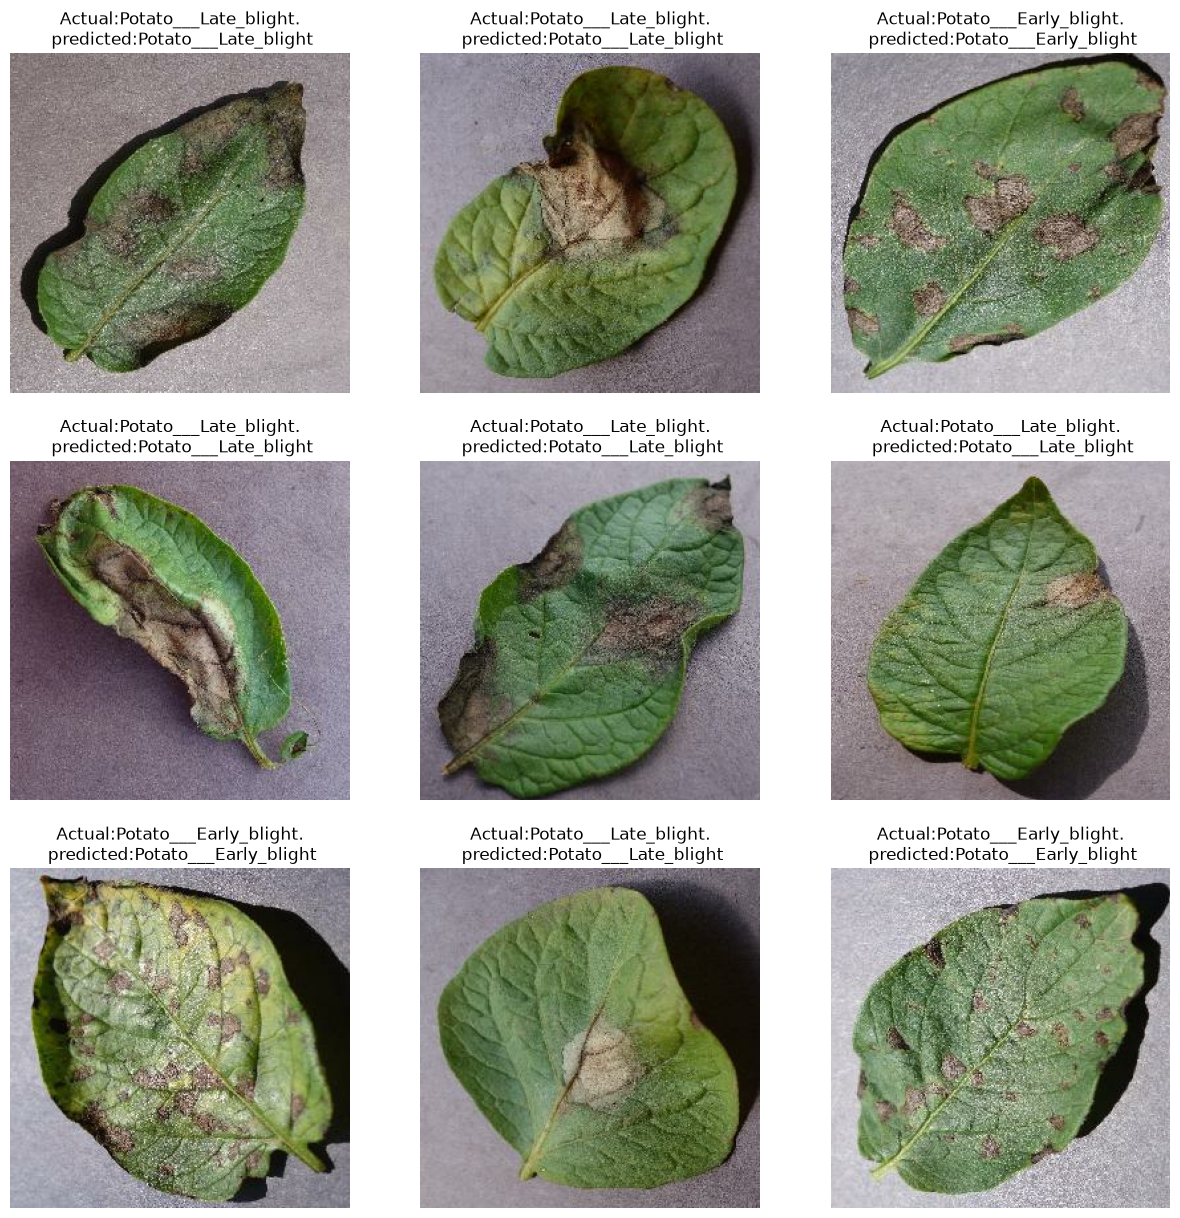

In [131]:
plt.figure(figsize=(15,15))
for images,label in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis('off')
        predicted_class,confidence=predict(model,images[i])
        actual_label = class_names[label[i]]
        plt.title(f"Actual:{actual_label}.\n predicted:{predicted_class}")

In [124]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [134]:
model_version=1.1
model.export(f"../models/potato-{model_version}")

INFO:tensorflow:Assets written to: ../models/potato-1.1/assets


INFO:tensorflow:Assets written to: ../models/potato-1.1/assets


Saved artifact at '../models/potato-1.1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  128705877550736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877551696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877549776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877552464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877552272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877552848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877553040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877553232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877554384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128705877553424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12870587